## 1. Predicción de Precios de Acciones.
Dado el historial de precios de una acción en los últimos 5 años, utiliza el
modelo ARIMA para predecir los precios en los próximos 6 meses.

In [22]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Cargar el csv

df_acciones = pd.read_csv('acciones_ki.csv')
df_acciones

,Fecha,Abrir,Máx.,Mín.,Cerrar,Cierre ajustado,Volumen
0,11 may 2026,"15,34","15,34","14,64","14,75","14,75",77.462
1,1 may 2026,"16,63","16,83","15,25","15,51","15,51",891.400
2,1 abr 2026,"14,72","19,42","14,18","16,67","16,67",2.641.600
3,1 mar 2026,"16,38","16,75","14,04","14,57","14,57",2.359.700
4,1 feb 2026,"15,24","17,39","14,86","16,48","16,43",2.445.400
5,1 ene 2026,"16,75","17,56","14,83","15,45","15,40",3.105.100
6,1 dic 2025,"15,19","17,89","14,71","16,83","16,78",2.904.400
7,1 nov 2025,"14,63","15,76","13,90","15,22","15,12",2.776.200
8,1 oct 2025,"14,70","15,65","14,22","14,58","14,49",3.085.600
9,1 sept 2025,"13,37","15,20","13,15","14,70","14,61",2.965.000


In [23]:
print(df_acciones.dtypes)
print(df_acciones['Cierre ajustado'].head())

# Limpieza robusta: quita símbolos y separadores de miles, y convierte a float
df_acciones['Cierre ajustado'] = (
    df_acciones['Cierre ajustado']
    .astype(str)
    .str.replace(',', '', regex=False)   # miles: 1,234.56 -> 1234.56
    .str.replace('$', '', regex=False)   # por si trae $
    .str.strip()
)

df_acciones['Cierre ajustado'] = pd.to_numeric(df_acciones['Cierre ajustado'], errors='coerce')

Fecha              object
Abrir              object
Máx.               object
Mín.               object
Cerrar             object
Cierre ajustado    object
Volumen            object
dtype: object
0    14,75
1    15,51
2    16,67
3    14,57
4    16,43
Name: Cierre ajustado, dtype: object


In [24]:
modelo = ARIMA(df_acciones['Cierre ajustado'], order=(1,1,1))
resultado = modelo.fit()
print(resultado.summary())

                               SARIMAX Results                                
Dep. Variable:        Cierre ajustado   No. Observations:                   54
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -331.401
Date:                Mon, 11 May 2026   AIC                            668.801
Time:                        10:51:53   BIC                            674.712
Sample:                             0   HQIC                           671.074
                                 - 54                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6352      0.417     -1.522      0.128      -1.453       0.183
ma.L1          0.4343      0.473      0.919      0.358      -0.492       1.360
sigma2      1.578e+04   1750.924      9.013      0.0

In [25]:
prediccion = resultado.forecast(steps=12)
print(prediccion)


54    515.445576
55    520.243846
56    517.196175
57    519.131935
58    517.902417
59    518.683358
60    518.187335
61    518.502389
62    518.302279
63    518.429381
64    518.348651
65    518.399928
Name: predicted_mean, dtype: float64


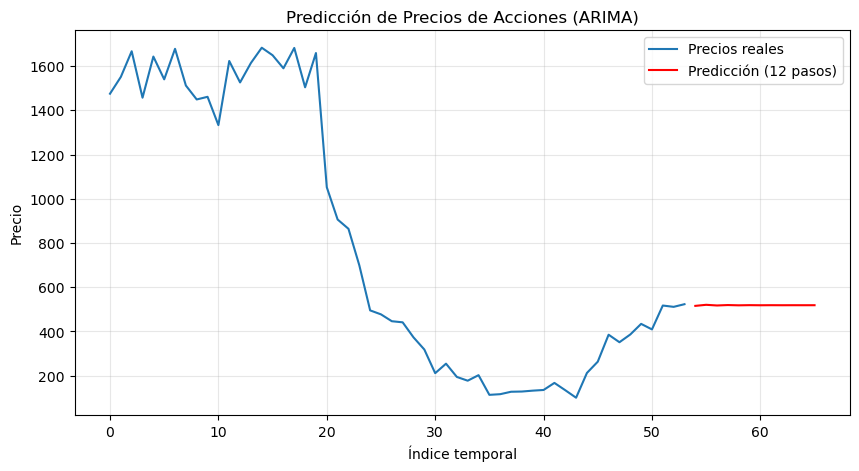

In [26]:
# Visualización correcta: histórico + pronóstico al final
plt.figure(figsize=(10, 5))
plt.plot(df_acciones.index, df_acciones['Cierre ajustado'], label='Precios reales')

plt.plot(prediccion.index, prediccion.values, label='Predicción (12 pasos)', color='red')

plt.title('Predicción de Precios de Acciones (ARIMA)')
plt.xlabel('Índice temporal')
plt.ylabel('Precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 2. Pronóstico de la Temperatura Mensual
Utiliza una serie temporal de temperaturas mensuales en una ciudad para
crear un modelo ARIMA que prediga las temperaturas del próximo año.

In [27]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Cargar el csv

df_clima = pd.read_csv('historico_mensual_clima_tokio.csv')
df_clima

,Mes,Máx (°C),Mín (°C),Promedio (°C)
0,Ene,10,3,6.5
1,Feb,11,4,7.5
2,Mar,14,6,10.0
3,Abr,19,11,15.0
4,May,23,16,19.5
5,Jun,26,20,23.0
6,Jul,30,24,27.0
7,Ago,31,25,28.0
8,Sep,27,22,24.5
9,Oct,22,16,19.0


In [28]:
modelo = ARIMA(df_clima['Promedio (°C)'], order=(1,1,1))
resultado = modelo.fit()
print(resultado.summary())

                               SARIMAX Results                                
Dep. Variable:          Promedio (°C)   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -20.306
Date:                Mon, 11 May 2026   AIC                             46.613
Time:                        10:52:39   BIC                             47.806
Sample:                             0   HQIC                            45.860
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7895      0.230      3.427      0.001       0.338       1.241
ma.L1          0.9990    118.953      0.008      0.993    -232.144     234.142
sigma2         1.5556    185.022      0.008      0.9

In [29]:
prediccion = resultado.forecast(steps=12)
print(prediccion)


12     4.135102
13     0.688962
14    -2.031807
15    -4.179888
16    -5.875823
17    -7.214785
18    -8.271911
19    -9.106526
20    -9.765464
21   -10.285703
22   -10.696439
23   -11.020719
Name: predicted_mean, dtype: float64


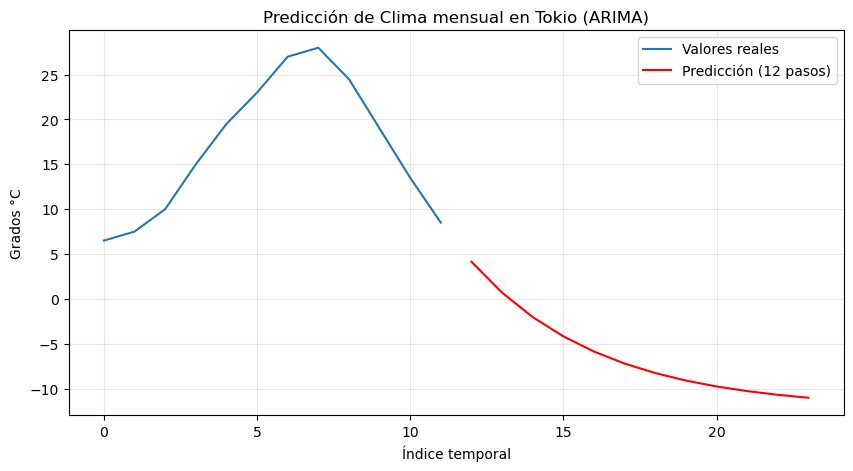

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(df_clima.index, df_clima['Promedio (°C)'], label='Valores reales')

plt.plot(prediccion.index, prediccion.values, label='Predicción (12 pasos)', color='red')

plt.title('Predicción de Clima mensual en Tokio (ARIMA)')
plt.xlabel('Índice temporal')
plt.ylabel('Grados °C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Análisis de Demanda Energética
A partir de los registros históricos de consumo de energía de una empresa,
realiza una predicción del consumo en el próximo trimestre utilizando
ARIMA.